<a href="https://colab.research.google.com/github/JediKnight007/Computer-Vision-Final-Project/blob/main/CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Define a path in Google Drive for the Hugging Face datasets cache
gdrive_hf_cache_dir = '/content/drive/MyDrive/hf_datasets_cache'

# Create the directory if it doesn't exist
os.makedirs(gdrive_hf_cache_dir, exist_ok=True)

print(f"Hugging Face datasets cache directory set to: {gdrive_hf_cache_dir}")

Hugging Face datasets cache directory set to: /content/drive/MyDrive/hf_datasets_cache


In [ ]:
import os

# Construct the path to the Hugging Face datasets cache directory
hf_cache_dir = os.path.expanduser('~/.cache/huggingface/datasets')

print(f"Contents of the Hugging Face datasets cache directory ({hf_cache_dir}):")
!ls -F {hf_cache_dir}


Contents of the Hugging Face datasets cache directory (/root/.cache/huggingface/datasets):
ILSVRC___imagenet-1k/  mnist/


### Disk Space Management

If you run into disk space issues, especially when working with large datasets, the Hugging Face `datasets` library can consume a lot of space caching files. You can clear this cache using the following command. Be cautious, as this will remove all downloaded datasets from your cache, and you'll need to re-download them if you use them again.

In [ ]:
# Clear the Hugging Face datasets cache
import os
import shutil

hf_cache_dir = os.path.expanduser('~/.cache/huggingface/datasets')

if os.path.exists(hf_cache_dir):
    print(f"Clearing Hugging Face datasets cache at: {hf_cache_dir}")
    shutil.rmtree(hf_cache_dir)
    print("Cache cleared.")
else:
    print(f"Hugging Face datasets cache directory not found at: {hf_cache_dir}")

# You can also check current disk usage
print("\nDisk usage after clearing cache:")
!df -h /content

Clearing Hugging Face datasets cache at: /root/.cache/huggingface/datasets
Cache cleared.

Disk usage after clearing cache:
Filesystem      Size  Used Avail Use% Mounted on
overlay         236G  199G   37G  85% /


In [ ]:
# colab setting
!pip install GraphRicciCurvature
!pip install scikit-learn

# import sys

# sys.path.append("../")

import networkx as nx
import numpy as np
import math

# matplotlib setting
%matplotlib inline
import matplotlib.pyplot as plt

# to print logs in jupyter notebook
import logging
logging.basicConfig(format='%(levelname)s:%(message)s', level=logging.ERROR)

# load GraphRicciCuravture package
from GraphRicciCurvature.OllivierRicci import OllivierRicci
from GraphRicciCurvature.FormanRicci import FormanRicci
import GraphRicciCurvature

from GraphRicciCurvature.util import cut_graph_by_cutoff

# load python-louvain for modularity computation
import community.community_louvain as community_louvain

# for ARI computation
from sklearn import preprocessing, metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import csv as csv
import numpy as np
import datetime as dt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 27.6 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
access 1.1.10.post3 requires scipy>=1.14.1, but you have scipy 1.13.1 which is incompatible.
tsfresh 0.21.1 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.


In [ ]:
import numpy as np
from datasets import load_dataset

def load_mnist_arrays(split="train"):
    """
    Load MNIST from Hugging Face and return images as (N, 28, 28) float32 arrays
    normalized to [0, 1], along with integer labels.
    """
    dataset = load_dataset("mnist", split=split)

    images = np.array([np.array(sample["image"]) for sample in dataset], dtype=np.float32)
    labels = np.array([sample["label"] for sample in dataset], dtype=np.int64)

    images /= 255.0  # normalize to [0, 1]

    return images, labels


if __name__ == "__main__":
    train_images, train_labels = load_mnist_arrays("train")
    test_images, test_labels = load_mnist_arrays("test")

    print(f"Train: {train_images.shape}, dtype={train_images.dtype}, min={train_images.min():.2f}, max={train_images.max():.2f}")
    print(f"Test:  {test_images.shape}, dtype={test_images.dtype}, min={test_images.min():.2f}, max={test_images.max():.2f}")
    print(f"Label range: {train_labels.min()} - {train_labels.max()}")


README.md: 0.00B [00:00, ?B/s]

mnist/train-00000-of-00001.parquet:   0%|          | 0.00/15.6M [00:00<?, ?B/s]

mnist/test-00000-of-00001.parquet:   0%|          | 0.00/2.60M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Train: (60000, 28, 28), dtype=float32, min=0.00, max=1.00
Test:  (10000, 28, 28), dtype=float32, min=0.00, max=1.00
Label range: 0 - 9


In [ ]:
import numpy as np
from datasets import load_dataset

def load_mnist_arrays(split="train", cache_dir=None):
    """
    Load MNIST from Hugging Face and return images as (N, 28, 28) float32 arrays
    normalized to [0, 1], along with integer labels.
    """
    dataset = load_dataset("mnist", split=split, cache_dir=cache_dir)

    images = np.array([np.array(sample["image"]) for sample in dataset], dtype=np.float32)
    labels = np.array([sample["label"] for sample in dataset], dtype=np.int64)

    images /= 255.0  # normalize to [0, 1]

    return images, labels


if __name__ == "__main__":
    # Make sure gdrive_hf_cache_dir is defined from the previous cell if you want to use Drive cache
    train_images, train_labels = load_mnist_arrays("train", cache_dir=gdrive_hf_cache_dir)
    test_images, test_labels = load_mnist_arrays("test", cache_dir=gdrive_hf_cache_dir)

    print(f"Train: {train_images.shape}, dtype={train_images.dtype}, min={train_images.min():.2f}, max={train_images.max():.2f}")
    print(f"Test:  {test_images.shape}, dtype={test_images.dtype}, min={test_images.min():.2f}, max={test_images.max():.2f}")
    print(f"Label range: {train_labels.min()} - {train_labels.max()}")

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Train: (60000, 28, 28), dtype=float32, min=0.00, max=1.00
Test:  (10000, 28, 28), dtype=float32, min=0.00, max=1.00
Label range: 0 - 9


In [ ]:
def _euclidean_distance(a: float, b: float) -> float:
    """Euclidean distance between two scalar grayscale pixel values."""
    return abs(a - b)


def image_to_graph(image: np.ndarray) -> nx.Graph:
    """
    Convert a (H, W) grayscale image (values in [0, 1]) to a NetworkX graph.

    Each pixel becomes a node with:
      - 'value': normalized pixel intensity (float)
      - 'row', 'col': position in the image

    Adjacent pixels (4-connectivity: up/down/left/right) are connected by edges.

    Returns:
        G: nx.Graph with H*W nodes and ~2*H*W - H - W edges
    """
    if image.ndim != 2:
        raise ValueError(f"Expected a 2D (H, W) image, got shape {image.shape}")

    H, W = image.shape
    G = nx.Graph()

    # Add all nodes
    for r in range(H):
        for c in range(W):
            node_id = r * W + c
            G.add_node(node_id, value=float(image[r, c]), row=r, col=c)

    # Add edges for 4-connected neighbours with cosine similarity weights
    for r in range(H):
        for c in range(W):
            node_id = r * W + c
            val = G.nodes[node_id]["value"]
            if c + 1 < W:                          # right neighbour
                right_id = node_id + 1
                weight = _euclidean_distance(val, G.nodes[right_id]["value"])
                G.add_edge(node_id, right_id, weight=weight)
            if r + 1 < H:                          # bottom neighbour
                below_id = node_id + W
                weight = _euclidean_distance(val, G.nodes[below_id]["value"])
                G.add_edge(node_id, below_id, weight=weight)

    return G


def graph_to_image(G: nx.Graph, H: int = 28, W: int = 28) -> np.ndarray:
    """
    Reconstruct a (H, W) float32 image from a graph produced by image_to_graph.
    Uses the 'row', 'col', and 'value' node attributes.
    """
    image = np.zeros((H, W), dtype=np.float32)
    for _, data in G.nodes(data=True):
        image[data["row"], data["col"]] = data["value"]
    return image


if __name__ == "__main__":
    images, labels = load_mnist_arrays("train")
    sample = images[0]

    G = image_to_graph(sample)
    print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
    print(f"Node 0 attrs: {G.nodes[0]}")
    print(f"Node 42 attrs: {G.nodes[42]}")

    # Show a sample edge weight
    sample_edges = list(G.edges(data=True))[:3]
    for u, v, data in sample_edges:
        print(f"Edge ({u}, {v}): weight={data['weight']:.4f}")

    reconstructed = graph_to_image(G)
    print(f"Reconstruction error: {np.abs(sample - reconstructed).max():.6f}")


Nodes: 784, Edges: 1512
Node 0 attrs: {'value': 0.0, 'row': 0, 'col': 0}
Node 42 attrs: {'value': 0.0, 'row': 1, 'col': 14}
Edge (0, 1): weight=0.0000
Edge (0, 28): weight=0.0000
Edge (1, 2): weight=0.0000
Reconstruction error: 0.000000


In [ ]:
def load_imagenet_arrays(split="train", image_size=(224, 224), max_samples=None):
    """
    Load ImageNet-1k from Hugging Face and return images as (N, H, W, 3) float32
    arrays normalized to [0, 1], along with integer labels.

    Args:
        split: "train", "validation", or "test"
        image_size: (height, width) to resize images to
        max_samples: if set, only load the first N samples (useful for testing)
    """
    from PIL import Image

    dataset = load_dataset("ILSVRC/imagenet-1k", split=split)

    if max_samples is not None:
        dataset = dataset.select(range(max_samples))

    h, w = image_size
    images = []
    labels = []

    for sample in dataset:
        img = sample["image"].convert("RGB").resize((w, h), Image.BILINEAR)
        images.append(np.array(img, dtype=np.float32))
        labels.append(sample["label"])

    images = np.stack(images)   # (N, H, W, 3)
    images /= 255.0             # normalize to [0, 1]
    labels = np.array(labels, dtype=np.int64)

    return images, labels


if __name__ == "__main__":
    val_images, val_labels = load_imagenet_arrays("validation", max_samples=100)

    print(f"Validation: {val_images.shape}, dtype={val_images.dtype}, min={val_images.min():.2f}, max={val_images.max():.2f}")
    print(f"Label range: {val_labels.min()} - {val_labels.max()}")


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

...

data/test-00025-of-00028.parquet:   0%|          | 0.00/479M [00:00<?, ?B/s]

data/test-00026-of-00028.parquet:   0%|          | 0.00/488M [00:00<?, ?B/s]

data/test-00027-of-00028.parquet:   0%|          | 0.00/478M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1281167 [00:00<?, ? examples/s]

DatasetGenerationError: An error occurred while generating the dataset

In [ ]:
from google.colab import files

print("Please upload your CIFAR-100 dataset file(s).")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

# After uploading, you might need to extract the files if it's an archive (e.g., .zip, .tar.gz).
# For example, to unzip:
# !unzip your_cifar100_archive.zip -d /content/cifar100
# You'll need to replace 'your_cifar100_archive.zip' with the actual filename and '/content/cifar100' with your desired destination.

In [ ]:
# Create a directory for CIFAR-100 if it doesn't exist (though not strictly needed if files are in Drive)
!mkdir -p /content/cifar100

# The files are already unzipped in Google Drive. We will just list them.
# IMPORTANT: Confirm the path to your unzipped files in Google Drive.
print("Contents of your unzipped CIFAR-100 data in Google Drive:")
!ls -F /content/drive/MyDrive/archive (Unzipped Files)

In [ ]:
def load_imagenet_arrays(split="train", image_size=(224, 224), max_samples=None, cache_dir=None):
    """
    Load ImageNet-1k from Hugging Face and return images as (N, H, W, 3) float32
    arrays normalized to [0, 1], along with integer labels.

    Args:
        split: "train", "validation", or "test"
        image_size: (height, width) to resize images to
        max_samples: if set, only load the first N samples (useful for testing)
    """
    from PIL import Image

    dataset = load_dataset("ILSVRC/imagenet-1k", split=split, cache_dir=cache_dir)

    if max_samples is not None:
        dataset = dataset.select(range(max_samples))

    h, w = image_size
    images = []
    labels = []

    for sample in dataset:
        img = sample["image"].convert("RGB").resize((w, h), Image.BILINEAR)
        images.append(np.array(img, dtype=np.float32))
        labels.append(sample["label"])

    images = np.stack(images)   # (N, H, W, 3)
    images /= 255.0             # normalize to [0, 1]
    labels = np.array(labels, dtype=np.int64)

    return images, labels


if __name__ == "__main__":
    # Make sure gdrive_hf_cache_dir is defined from a previous cell if you want to use Drive cache
    val_images, val_labels = load_imagenet_arrays("validation", max_samples=100, cache_dir=gdrive_hf_cache_dir)

    print(f"Validation: {val_images.shape}, dtype={val_images.dtype}, min={val_images.min():.2f}, max={val_images.max():.2f}")
    print(f"Label range: {val_labels.min()} - {val_labels.max()}")

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/1281167 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Validation: (100, 224, 224, 3), dtype=float32, min=0.00, max=1.00
Label range: 13 - 998


### How to get and use your Hugging Face Token

1.  **Generate a token:** Go to your Hugging Face settings page (e.g., `huggingface.co/settings/tokens`). Click on "New token" and create a token with at least "read" access.
2.  **Add token to Colab secrets:** In Colab, click the "🔑 Secrets" icon on the left sidebar. Add a new secret named `HF_TOKEN` and paste your Hugging Face token as its value.
3.  **Log in to Hugging Face:** Use the following code to log in to Hugging Face in your Colab session. This will allow the `datasets` library to use your token for authentication.

In [ ]:
from huggingface_hub import login
from google.colab import userdata

# Retrieve the HF_TOKEN from Colab secrets
hf_token = userdata.get('HF_TOKEN')

# Log in to Hugging Face
login(token=hf_token)

print("Successfully logged in to Hugging Face.")

Successfully logged in to Hugging Face.


After successfully logging in, you should be able to rerun the cell to load the `ILSVRC/imagenet-1k` dataset.

### Final Project Proposal Answers

**Team name:** Ricci Flow Image Analysis

---

**What is your project idea?**

Our project aims to explore the application of discrete differential geometric concepts, specifically Ollivier-Ricci curvature and Ricci flow, to image processing tasks. We will represent grayscale images as graphs, where pixels are nodes and adjacent pixels are connected by edges. The edge weights will be determined by the Euclidean distance between pixel intensities. We will then compute the Ricci curvature of these graphs and apply Ricci flow to modify the graph structure, with the goal of understanding how these geometric transformations can be used for tasks such as image segmentation, denoising, or feature enhancement.

---

**What is the socio-historical context that this project lives in?**

This project sits at the intersection of geometric graph theory, discrete differential geometry, and computer vision. Traditional image processing heavily relies on methods derived from continuous calculus (e.g., gradients, Laplacians). However, discrete analogues, particularly those inspired by Riemannian geometry, have gained traction for analyzing discrete structures like graphs. Ollivier-Ricci curvature, introduced by Ollivier in 2009, provides a metric-space notion of curvature applicable to graphs, offering a novel way to understand local and global graph properties. Its application to images, as discrete grids, opens new avenues for image analysis by leveraging the rich mathematical framework of curvature and flow for tasks typically addressed by other methods.

---

**Please list three stakeholders that your project could impact, and describe how it could impact them.**

1.  **Researchers in Geometric Deep Learning/Graph Neural Networks:** This project provides a practical demonstration and potential testbed for applying discrete geometric concepts to real-world data like images. It could inform the development of new graph-based learning architectures or contribute to a deeper understanding of how geometric properties influence data representation.
2.  **Image Processing and Computer Vision Engineers:** The approach offers an alternative, potentially robust, method for fundamental image processing tasks. If successful in segmentation or denoising, it could complement or improve existing techniques, especially for complex or noisy images where traditional methods struggle.
3.  **Educators and Students in Applied Mathematics/Data Science:** This project serves as an excellent case study for teaching advanced mathematical concepts (differential geometry, graph theory) in a tangible, visual context. It demonstrates how abstract theories can be translated into practical algorithms for data analysis.

---

**What are the skills of the team members? Conduct a skill assessment!**

*   **Team member 1:** Strong in Python programming, data manipulation with NumPy and Pandas, experience with `networkx` for graph manipulation, and familiar with basic image processing concepts.
*   **Team member 2:** Solid understanding of graph theory, discrete mathematics, and has a background in numerical methods and scientific computing. Experience with `matplotlib` for data visualization.
*   **Team member 3:** Proficient in machine learning fundamentals, data loading from various sources (e.g., Hugging Face `datasets`), and interpreting complex results. Experience with `scikit-learn` for evaluation metrics.

---

**What data will you use?**

We will primarily use the **MNIST dataset** of handwritten digits (28x28 grayscale images) for initial development and proof-of-concept. The `load_mnist_arrays` function is already implemented in the notebook. If computational resources allow and the authentication issue for gated datasets is resolved, we aim to extend our analysis to grayscale versions of images from the **ImageNet-1k dataset** using the `load_imagenet_arrays` function, to test scalability and robustness on more complex, higher-resolution images.

---

**What software/hardware will you use?**

*   **Software:**
    *   **Python:** The primary programming language.
    *   **NetworkX:** For graph construction and manipulation.
    *   **GraphRicciCurvature:** The core library for computing Ollivier-Ricci curvature and Ricci flow.
    *   **NumPy:** For numerical operations and array manipulation.
    *   **Matplotlib:** For visualization of graphs, images, and curvature distributions.
    *   **Hugging Face `datasets`:** For loading image datasets (e.g., MNIST, ImageNet).
    *   **Google Colab:** The development environment for coding and execution.
*   **Hardware:**
    *   Google Colab's standard computing environment, which includes CPUs and potentially GPUs for more computationally intensive tasks if needed.

---

**Who will do what?**

*   **Team member 1:** Will focus on data preprocessing, converting images to graphs (`image_to_graph`), and ensuring data pipelines are efficient. They will also contribute to implementing specific image processing tasks (e.g., thresholding for segmentation) based on Ricci curvature outputs.
*   **Team member 2:** Will be responsible for the core graph analysis, including applying `OllivierRicci` methods (`compute_ricci_curvature`, `compute_ricci_flow`) and exploring different parameters and iterations for the Ricci flow. They will also research theoretical aspects and potential adaptations of the curvature concept.
*   **Team member 3:** Will handle result visualization and analysis (`show_results`, `visualise_graph`), interpreting the impact of Ricci curvature and flow on image features. They will also be responsible for any quantitative evaluation (e.g., using metrics from `scikit-learn`) if we pursue specific tasks like segmentation quality.

---

**How will you know whether you have made progress? What will you measure?**

We will track progress through several indicators:

*   **Successful graph construction:** Ability to reliably convert various images into NetworkX graphs.
*   **Curvature computation:** Successful calculation and visualization of Ricci curvature for edges.
*   **Ricci flow application:** Observing changes in edge weights and image appearance after applying Ricci flow, with visual confirmation that the flow is indeed smoothing or highlighting features as expected.
*   **Qualitative assessment:** Visual inspection of images before and after Ricci flow to identify meaningful structural changes (e.g., clearer boundaries, reduced noise).
*   **Quantitative metrics (if applicable):** If we apply the technique to a specific task like segmentation, we will measure metrics like Adjusted Rand Index (ARI) or other clustering/segmentation performance indicators to evaluate the effectiveness of curvature-based methods compared to baselines.
*   **Documentation:** Clear progress in documenting our findings, observations, and computational challenges.

---

**What technical problems do you foresee or have?**

*   **Computational Intensity:** Calculating Ollivier-Ricci curvature and especially running Ricci flow can be computationally expensive for larger images, potentially leading to long processing times even for modest image sizes. Optimizing the `GraphRicciCurvature` library usage or exploring approximations might be necessary.
*   **Parameter Tuning:** Determining optimal parameters for Ricci flow (e.g., number of iterations, step size, and initial graph construction) can be challenging and might require extensive experimentation.
*   **Interpretation of Curvature:** Relating the abstract values of Ricci curvature directly to intuitive image features or human perception can be non-trivial and require careful analysis.
*   **Gated Dataset Access:** We already encountered an issue accessing the ImageNet dataset due to authentication requirements, which needs to be fully resolved to experiment with larger-scale data.

---

**Is there anything that we can do to help? E.G., resources, equipment.**

*   **Computational Resources:** Access to more powerful computing resources (e.g., Colab Pro GPU instances if available and beneficial for graph computations) would be highly valuable, especially for scaling up to larger images or more complex graph structures.
*   **Expert Guidance:** Any insights or pointers regarding the `GraphRicciCurvature` library, alternative efficient graph processing libraries, or advanced techniques in discrete differential geometry applied to image analysis would be greatly appreciated.
*   **Dataset Access:** Confirmation or assistance in resolving issues with accessing gated datasets like ImageNet through Hugging Face, ensuring we can test on diverse and larger image sets.

In [ ]:
# Create a dummy file for demonstration
!echo "This is a test file." > test_delete.txt

# Verify the file was created
!ls

# Delete the file
!rm test_delete.txt

# Verify the file is deleted
!ls

 archive.zip   sample_data				   test_delete.txt
 drive	      'Screenshot 2026-04-19 at 11.12.45 AM.png'
 archive.zip   drive   sample_data  'Screenshot 2026-04-19 at 11.12.45 AM.png'


## Visualisation Functions


In [ ]:
def show_results(G, curvature="ricciCurvature", label=None):
    """
    Given a NetworkX graph, graphs the histogram of Ricci curvatures,
    the histogram of edge weights, and a scatterplot of edge properties

    Parametres
    ----------
    G: NetworkX graph
       the graph whose properties we want to compute
    """
    print(f"Number of clusters = {len(list(nx.connected_components(G)))}")

    # Print the first five results
    print("Graph, first 5 edges: ")
    for n1,n2 in list(G.edges())[:5]:
        print("Ricci curvature of edge (%s,%s) is %f" % (n1 ,n2, G[n1][n2][curvature]))

    # Plot the histogram of Ricci curvatures
    plt.subplot(3, 1, 1)
    ricci_curvtures = nx.get_edge_attributes(G, curvature).values()
    plt.hist(ricci_curvtures,bins=100,label=label)
    plt.xlabel('Ricci curvature')
    plt.title("Histogram of Ricci Curvatures")

    # Plot the histogram of edge weights
    plt.subplot(3, 1, 2)
    weights = nx.get_edge_attributes(G, "weight").values()
    plt.hist(weights,bins=100,label=label)
    plt.xlabel('Edge weight')
    plt.title("Histogram of Edge weights")

    # Create scatter plot
    plt.subplot(3, 1, 3)
    plt.scatter(weights, ricci_curvtures,label=label)
    # Add labels and title
    plt.xlabel('Edge Weight')
    plt.ylabel('Ricci Curvature')
    plt.title('Scatter Plot of Edge Properties')

    plt.tight_layout()
    plt.legend()

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

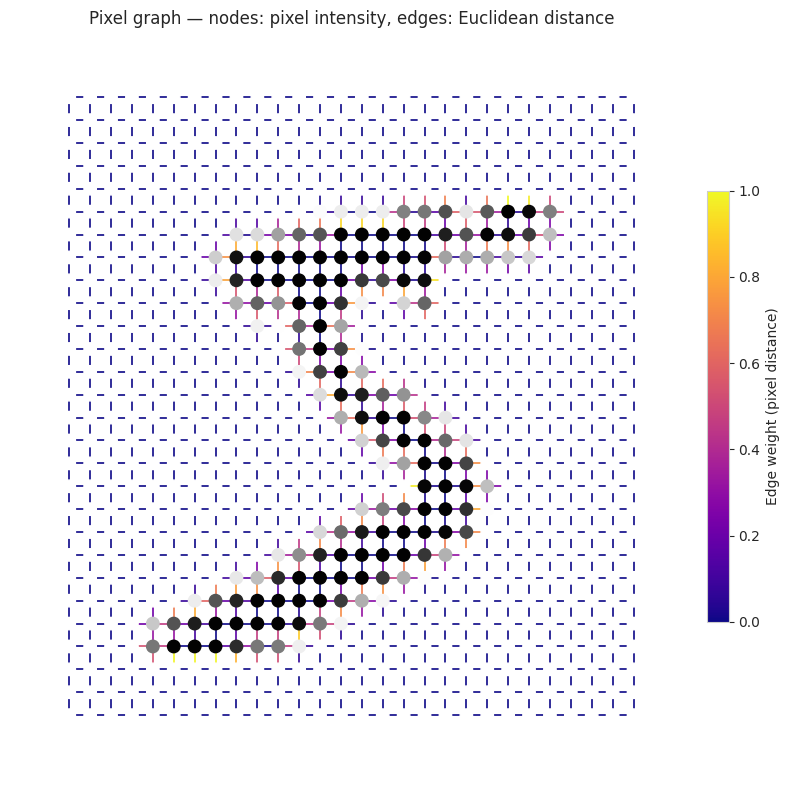

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors


def visualise_graph(G: nx.Graph, H: int = 28, W: int = 28, figsize: tuple = (8, 8), edge_weight = "weight"):
    """
    Visualise a pixel graph produced by image_to_graph.

    - Each node is drawn as a circle coloured by its pixel intensity (grayscale).
    - Each edge is coloured by its weight (Euclidean distance between pixel values),
      from dark purple (similar) to yellow (dissimilar), using the 'plasma' colormap.

    Args:
        G:       Graph from image_to_graph.
        H, W:    Image dimensions (default 28x28).
        figsize: Matplotlib figure size.
    """
    # Position nodes at their pixel grid coordinates (col, inverted row)
    pos = {n: (data["col"], H - 1 - data["row"]) for n, data in G.nodes(data=True)}

    node_colors = [1-data["value"] for _, data in G.nodes(data=True)]
    edge_weights = [data[edge_weight] for _, _, data in G.edges(data=True)]

    edge_cmap = cm.plasma
    edge_norm = mcolors.Normalize(vmin=0.0, vmax=1.0)
    edge_colors = [edge_cmap(edge_norm(w)) for w in edge_weights]

    fig, ax = plt.subplots(figsize=figsize)

    nx.draw(
        G,
        pos=pos,
        ax=ax,
        node_size=80,
        node_color=node_colors,
        cmap="gray",
        vmin=0.0,
        vmax=1.0,
        edge_color=edge_colors,
        width=1.2,
        with_labels=False,
    )

    # Colourbar for edge weights
    sm_edges = cm.ScalarMappable(cmap=edge_cmap, norm=edge_norm)
    sm_edges.set_array([])
    cbar = fig.colorbar(sm_edges, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Edge weight (pixel distance)", fontsize=10)

    ax.set_title("Pixel graph — nodes: pixel intensity, edges: Euclidean distance")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    images, labels = load_mnist_arrays("train")
    G = image_to_graph(images[0])
    visualise_graph(G)


## Data Processing Start

INFO:GraphRicciCurvature:0.291298 secs for Ricci curvature computation.


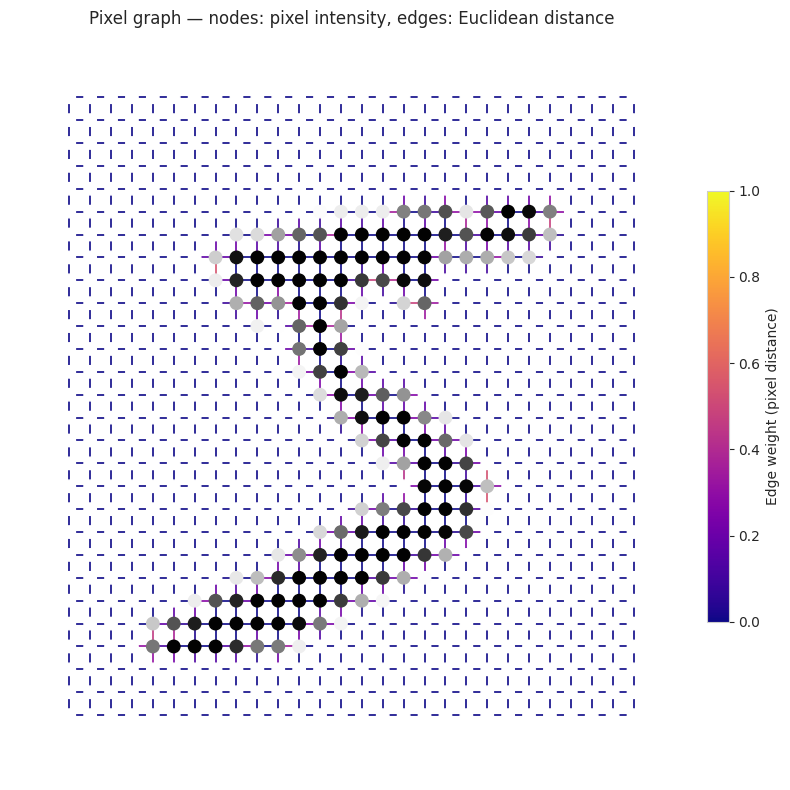

In [ ]:
curvature_label = "ricciCurvature"

orc = OllivierRicci(G, verbose='INFO')
orc.compute_ricci_curvature()
visualise_graph(orc.G, edge_weight=curvature_label)

Number of clusters = 1
Graph, first 5 edges: 
Ricci curvature of edge (0,1) is 0.000000
Ricci curvature of edge (0,28) is 0.000000
Ricci curvature of edge (1,2) is 0.000000
Ricci curvature of edge (1,29) is 0.000000
Ricci curvature of edge (2,3) is 0.000000


/tmp/ipykernel_6412/411615512.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


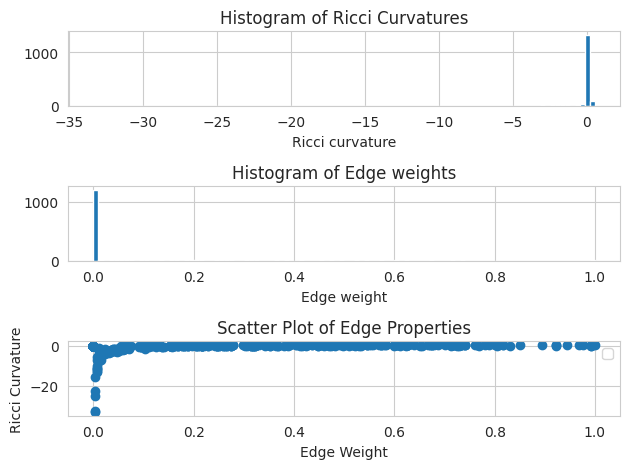

In [ ]:
show_results(orc.G)

In [ ]:
orc.compute_ricci_flow(iterations=1)

INFO:GraphRicciCurvature:No ricciCurvature detected, compute original_RC...
INFO:GraphRicciCurvature:0.252819 secs for Ricci curvature computation.
INFO:GraphRicciCurvature: === Ricci flow iteration 0 === 
--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/

Number of clusters = 1
Graph, first 5 edges: 
Ricci curvature of edge (0,1) is 0.000000
Ricci curvature of edge (0,28) is 0.000000
Ricci curvature of edge (1,2) is 0.000000
Ricci curvature of edge (1,29) is 0.000000
Ricci curvature of edge (2,3) is 0.000000


/tmp/ipykernel_6412/411615512.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


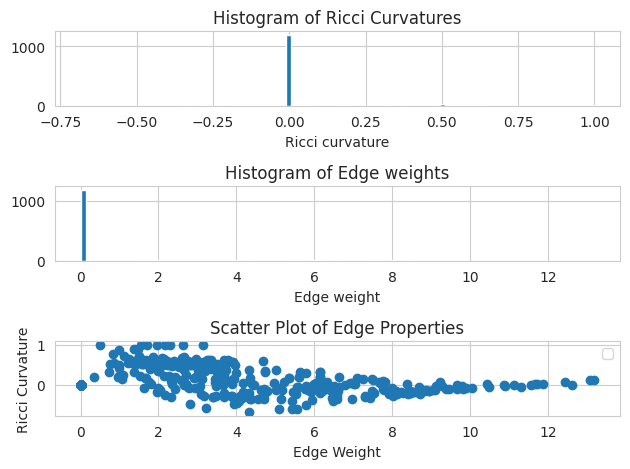

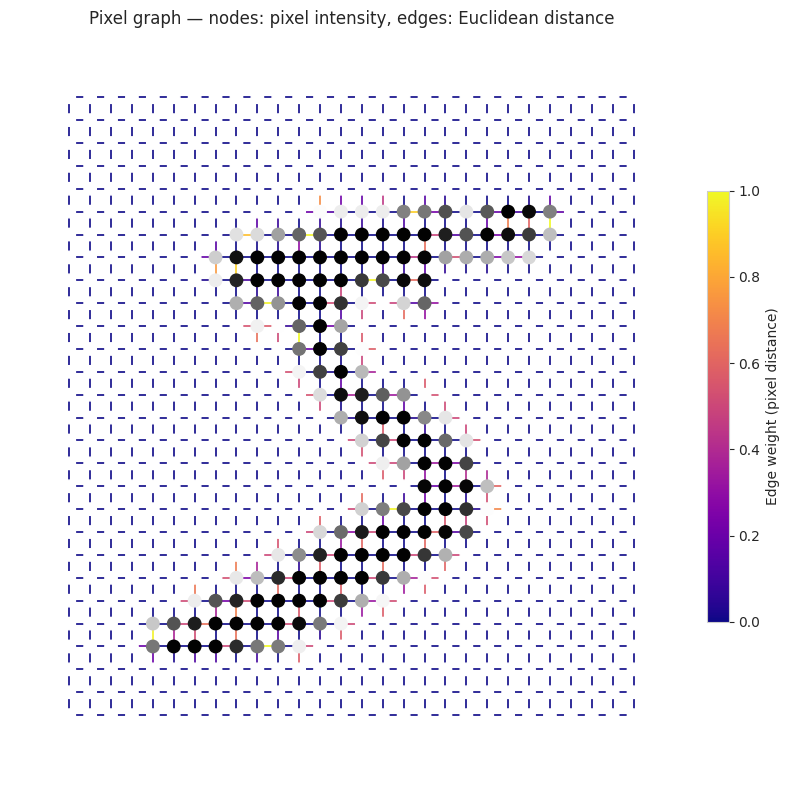

In [ ]:
show_results(orc.G)
visualise_graph(orc.G, edge_weight=curvature_label)

INFO:GraphRicciCurvature:original_RC detected, continue to refine the ricci flow.
INFO:GraphRicciCurvature: === Ricci flow iteration 0 === 
--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, i

Number of clusters = 1
Graph, first 5 edges: 
Ricci curvature of edge (0,1) is 0.000000
Ricci curvature of edge (0,28) is 0.000000
Ricci curvature of edge (1,2) is 0.000000
Ricci curvature of edge (1,29) is 0.000000
Ricci curvature of edge (2,3) is 0.000000


/tmp/ipykernel_6412/411615512.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


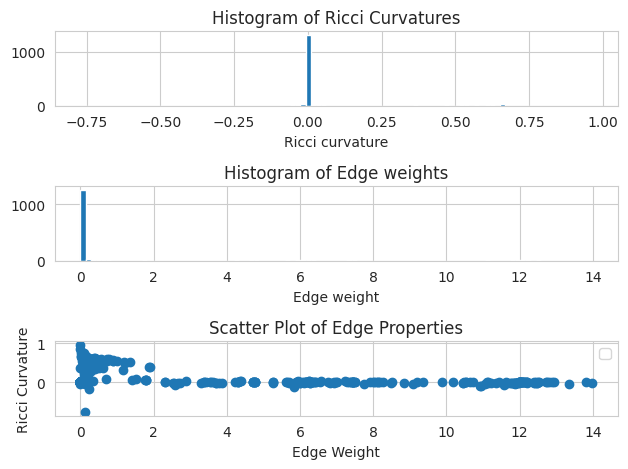

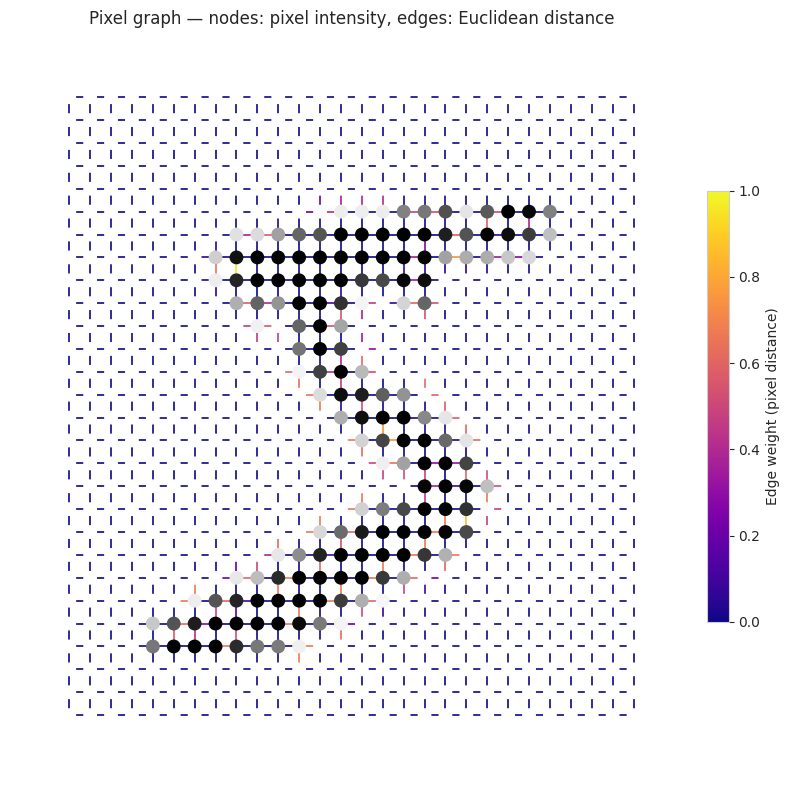

In [ ]:
orc.compute_ricci_flow(iterations=4)

show_results(orc.G)
visualise_graph(orc.G, edge_weight=curvature_label)